 ## 딥러닝을 가능케한 autograd

In [1]:
import torch
x = torch.tensor([1.],requires_grad=True) # float 이여야해서 1.
print(x) # ruquires_grad=True 일 때만 출력에 보여줌. default는 False

tensor([1.], requires_grad=True)


In [2]:
x = torch.tensor([1.])
print(x)
print(x.requires_grad)

x.requires_grad=True
print(x)
print(x.requires_grad)

tensor([1.])
False
tensor([1.], requires_grad=True)
True


In [3]:
x = torch.tensor([1.], requires_grad=True)
y = x**2
print(y)

print(x.grad)
y.backward() # y를 requires_grad=True인 변수에 대해 미분해줘.
print(x.grad) # y = x**2 을 미분한 2x의 x 값에 1을 대입한 gradient 값

tensor([1.], grad_fn=<PowBackward0>)
None
tensor([2.])


In [4]:
x = torch.tensor([1.], requires_grad=True)
y = x**2
print(y)
# tensor([1.], grad_fn=<PowBackward0>) 여기서 마지막 연산에 대한 정보를 grad_fn으로 보여줌.
y.retain_grad() # 이걸 해야 y.grad 가 오류가 안 생김.

z = 3*y
print(z)
# tensor([3.], grad_fn=<MulBackward0>) 마지막 연산인 *에 대한 정보를 보여주지만 제곱에 대한 연산 정보도 들어있음

z.backward()
print(x.grad) # chain rule로 알아냄
print(y.grad)

tensor([1.], grad_fn=<PowBackward0>)
tensor([3.], grad_fn=<MulBackward0>)
tensor([6.])
tensor([3.])


In [5]:
x = torch.tensor([1.], requires_grad=True)
y = x**2
z = 3*y

y.backward() # 이렇게하면 y에서 부터 뒤로 넘어감. 중간 변수에 대한 미분도 가능!
print(x.grad)

tensor([2.])


In [6]:
x = torch.tensor([1.], requires_grad=True)
a = x**2
b = a+1
print(b)
# tensor([2.], grad_fn=<AddBackward0>)
c = b**2
c.backward()
print(x.grad)

tensor([2.], grad_fn=<AddBackward0>)
tensor([8.])


In [7]:
x = torch.tensor([1.], requires_grad=True)
y = torch.tensor([1.], requires_grad=True)
z = 2*x**2 + y**2
print(z)
z.backward() # requires_grad=True 인 변수들에 대해 각각 편미분 수행
print(x.grad)
print(y.grad)

tensor([3.], grad_fn=<AddBackward0>)
tensor([4.])
tensor([2.])


In [8]:
x = torch.tensor([1., 2., 3.], requires_grad=True)
y = torch.sum(x**2) # x1**2 + x2**2 + x3**2
y.backward()

print(y)
print(x.grad) # 스칼라를 벡터로 미분

tensor(14., grad_fn=<SumBackward0>)
tensor([2., 4., 6.])


In [9]:
x = torch.tensor([1.], requires_grad=True)
x.requires_grad=False
# transfer learning 할 때 필요
# 모델에서 일부분만 학습을 시키고 싶을 때 필요한 변수들만 True, 나머지는 False로 놓고 학습 시키면 됨.
y = x**2
print(y)
# y.backward() # error!

tensor([1.])


In [10]:
x = torch.tensor([2.], requires_grad=True)
x2 = x.detach() # detach는 requires_grad_False 인 새로운 tensor를 만드는 것
print(x)
print(x2)
y = x**2
print(y)
y2 = x2**2
print(y2)

tensor([2.], requires_grad=True)
tensor([2.])
tensor([4.], grad_fn=<PowBackward0>)
tensor([4.])


In [11]:
# detach 사용 용도
x = torch.tensor([1.], requires_grad=True)
y = x**2
z = y.detach()  # x로 만든 것을 상수로 사용하고 싶은 것. 
                # y.requires_grad=False 이런 식으로 중간에 상수로 바꿀 수는 없음.
w = y+z # x**2 + 1과 같다

w.backward()
print(x.grad)

tensor([2.])


In [12]:
# 많이 쓰이는 torch.no_grad
x = torch.tensor([1.], requires_grad=True)
# chain rule을 위해 계속 grad_fn을 update 하니까 grad_fn을 잠시 계산하고 싶지 않을 때 torch.no_grad 사용
# 모델 테스트 시에는 미분할 일이 없어서 불필요하게 메모리를 쓸 필요가 없기 때문.
with torch.no_grad():
    y = x**2
    print(x.requires_grad) # x.requires_grad 가 False로 잠깐 바뀐 것은 아님.
    print(y) # with 안에서 계산되는 변수는 grad_fn이 붙지 않음
print(x.requires_grad)
# y.backward() # error!

y = x**2
print(y)

x=torch.tensor([1.], requires_grad=True)
x.requires_grad=False
y = x**2
print(x.requires_grad)
print(y)
# y.backward() # error!

True
tensor([1.])
True
tensor([1.], grad_fn=<PowBackward0>)
False
tensor([1.])


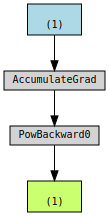

In [13]:
!pip install torchviz
from torchviz import make_dot
x = torch.tensor([1.],requires_grad=True)
# make_dot(x)
make_dot(x**2) # (1) 이라고 써 있는 것은 shape을 나타냄

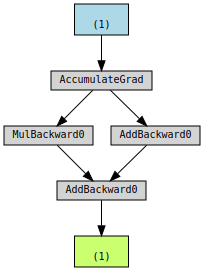

In [14]:
y = 2*x
z = 3+x
r = y+z
make_dot(r)

In [15]:
r.backward()
print(x.grad)

tensor([3.])
